In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv("/kaggle/input/unsw-nb15/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("/kaggle/input/unsw-nb15/UNSW_NB15_testing-set.csv")

In [3]:
combined_df = pd.concat([train_df, test_df], ignore_index=True)

In [4]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non-null  int64  
 16  si

In [5]:
columns_to_drop = ['id', 'proto', 'service', 'state', 'label']

combined_df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [6]:
combined_df.head()

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.000011,2,0,496,0,90909.0902,254,0,180363632.0,0.0,...,1,1,2,0,0,0,1,2,0,Normal
1,0.000008,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,...,1,1,2,0,0,0,1,2,0,Normal
2,0.000005,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,...,1,1,3,0,0,0,1,3,0,Normal
3,0.000006,2,0,900,0,166666.6608,254,0,600000000.0,0.0,...,2,1,3,0,0,0,2,3,0,Normal
4,0.000010,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,...,2,1,3,0,0,0,2,3,0,Normal


In [7]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [8]:
le = LabelEncoder()

combined_df['attack_cat_label'] = le.fit_transform(combined_df['attack_cat'])

In [9]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))

sorted_mapping = {k: mapping[k] for k in sorted(mapping, key=mapping.get)}

for category, label in sorted_mapping.items():
    print(f"'{category}': {label}")

'Analysis': 0
'Backdoor': 1
'DoS': 2
'Exploits': 3
'Fuzzers': 4
'Generic': 5
'Normal': 6
'Reconnaissance': 7
'Shellcode': 8
'Worms': 9


In [13]:
output_df = combined_df[['attack_cat', 'attack_cat_label']]

combined_df.to_csv('cyber_attack.csv')

In [12]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 41 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   spkts              257673 non-null  int64  
 2   dpkts              257673 non-null  int64  
 3   sbytes             257673 non-null  int64  
 4   dbytes             257673 non-null  int64  
 5   rate               257673 non-null  float64
 6   sttl               257673 non-null  int64  
 7   dttl               257673 non-null  int64  
 8   sload              257673 non-null  float64
 9   dload              257673 non-null  float64
 10  sloss              257673 non-null  int64  
 11  dloss              257673 non-null  int64  
 12  sinpkt             257673 non-null  float64
 13  dinpkt             257673 non-null  float64
 14  sjit               257673 non-null  float64
 15  djit               257673 non-null  float64
 16  sw

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

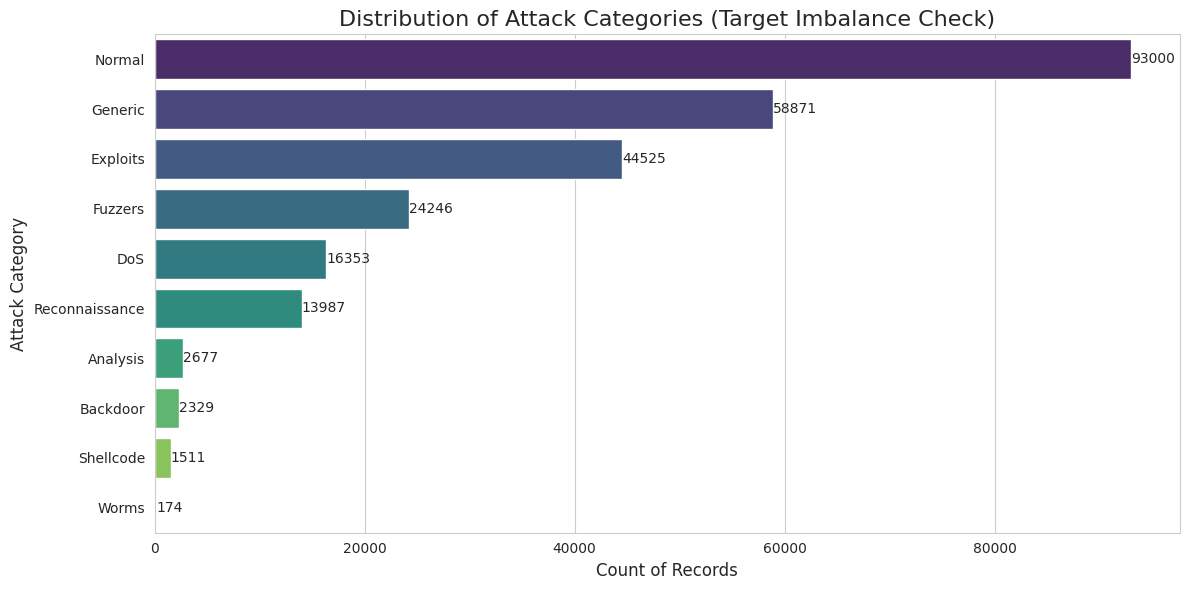

In [16]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(y='attack_cat', data=combined_df, order=combined_df['attack_cat'].value_counts().index, palette='viridis')
plt.title('Distribution of Attack Categories (Target Imbalance Check)', fontsize=16)
plt.xlabel('Count of Records', fontsize=12)
plt.ylabel('Attack Category', fontsize=12)

for container in ax.containers:
    ax.bar_label(container)
    
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


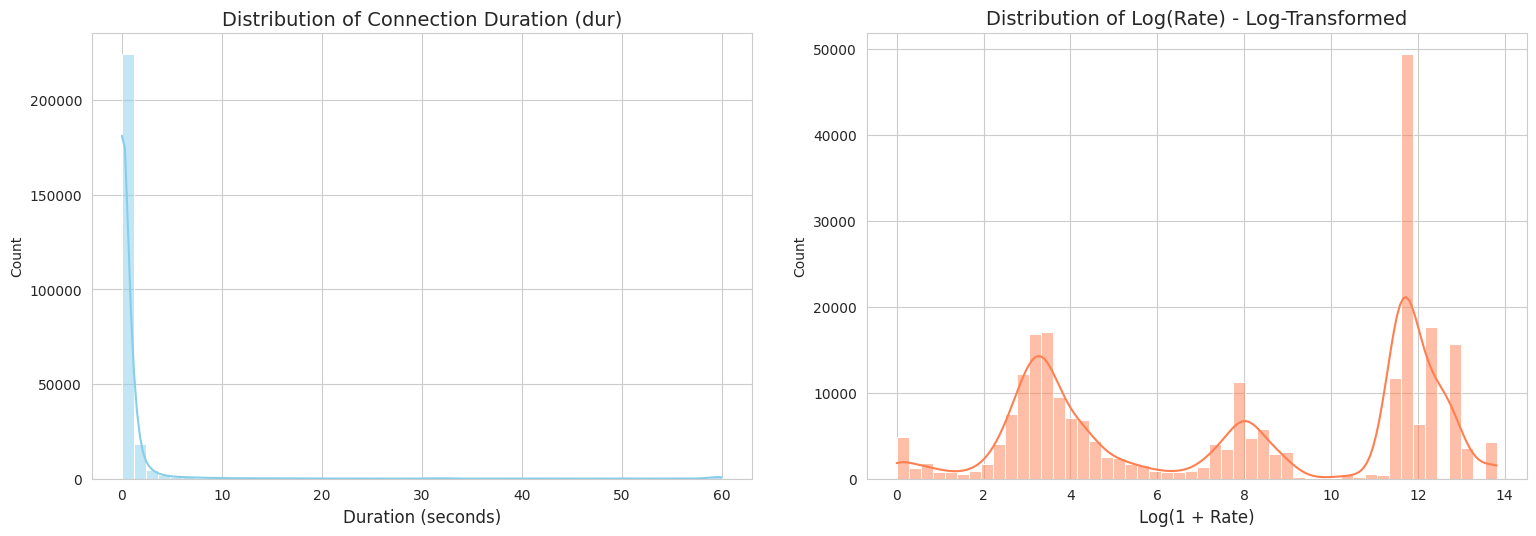

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(combined_df['dur'], kde=True, ax=axes[0], color='skyblue', bins=50)
axes[0].set_title('Distribution of Connection Duration (dur)', fontsize=14)
axes[0].set_xlabel('Duration (seconds)', fontsize=12)

sns.histplot(np.log1p(combined_df['rate']), kde=True, ax=axes[1], color='coral', bins=50)
axes[1].set_title('Distribution of Log(Rate) - Log-Transformed', fontsize=14)
axes[1].set_xlabel('Log(1 + Rate)', fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

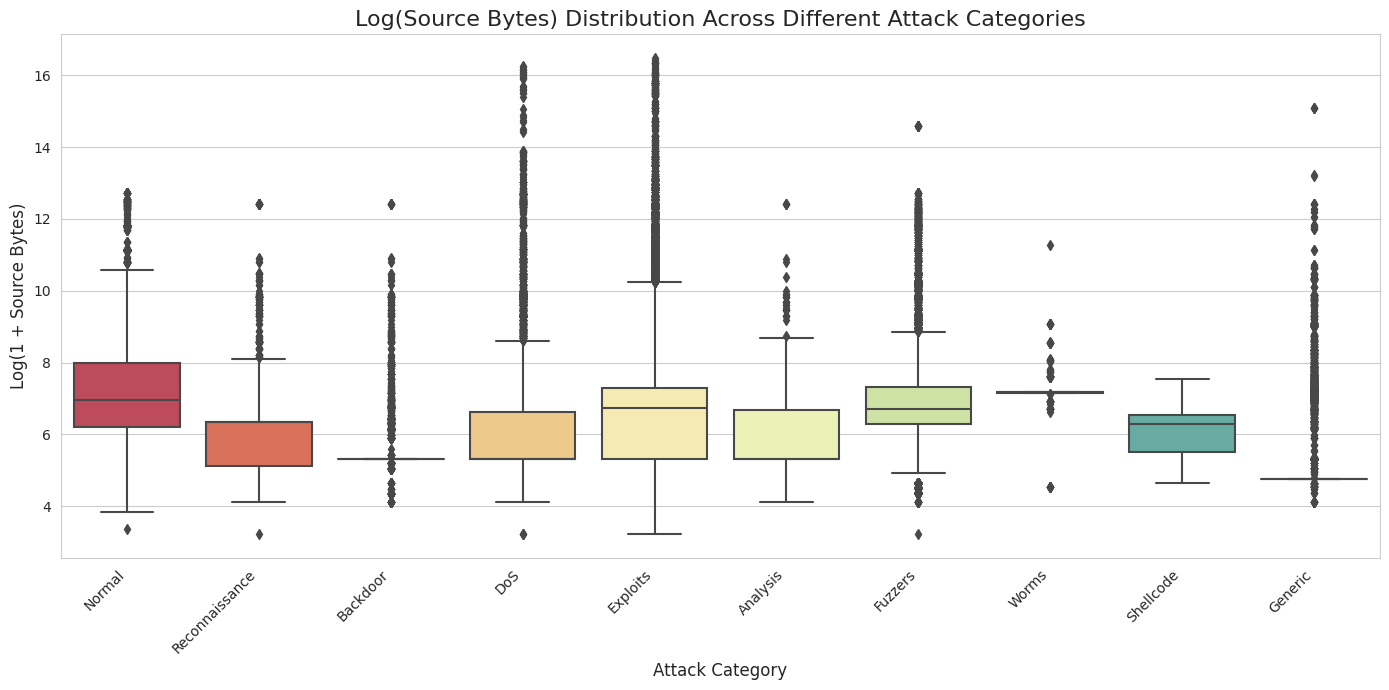

In [18]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='attack_cat', y=np.log1p(combined_df['sbytes']), data=combined_df, palette='Spectral')

plt.xticks(rotation=45, ha='right')
plt.title('Log(Source Bytes) Distribution Across Different Attack Categories', fontsize=16)
plt.xlabel('Attack Category', fontsize=12)
plt.ylabel('Log(1 + Source Bytes)', fontsize=12)

plt.tight_layout()
plt.show() 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("model\cyber_attack.csv")

In [3]:
df.isnull().sum()

dur                  0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat           0
attack_cat_label     0
dtype: int64

In [6]:
df['attack_cat'].unique()
df['attack_cat'].value_counts()

attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64

In [7]:
merge_classes = [
    'Fuzzers', 'DoS', 'Reconnaissance', 
    'Analysis', 'Backdoor', 'Shellcode', 'Worms'
]

In [8]:
df['attack_cat_merged'] = df['attack_cat'].replace(merge_classes, 'Other')

In [9]:
df['attack_cat_merged'].value_counts()

attack_cat_merged
Normal      93000
Other       61277
Generic     58871
Exploits    44525
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le = LabelEncoder()

In [12]:
df['attack_cat_merged_labeled'] = le.fit_transform(df['attack_cat_merged'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:")
for k, v in label_mapping.items():
    print(f"{k}: {v}")


Label Mapping:
Exploits: 0
Generic: 1
Normal: 2
Other: 3


In [13]:
df.columns

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl',
       'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit',
       'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat',
       'attack_cat_label', 'attack_cat_merged', 'attack_cat_merged_labeled'],
      dtype='object')

In [14]:
df = df.drop(columns=['attack_cat', 'attack_cat_label'])

In [15]:
df.columns

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl',
       'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit',
       'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat_merged',
       'attack_cat_merged_labeled'],
      dtype='object')

In [16]:
df.to_csv('attack_data.csv')